# Surface de Volatilité Implicite

In [50]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from src.data_loader import get_option_chain_data
from src.options_pricer import BlackScholesPricer

In [51]:
df_options = get_option_chain_data('NVDA', min_days_to_expiration=5)

r = 0.045

S0_current = df_options['S0'].iloc[0]
min_strike = S0_current * 0.80
max_strike = S0_current * 1.20

df_atm = df_options[
    (df_options['K'] >= min_strike) & 
    (df_options['K'] <= max_strike)
].copy()

print(f"Prix actuel NVDA : {S0_current:.2f} $")
print(f"Fenêtre de strikes : [{min_strike:.0f} $, {max_strike:.0f} $]")
print(f"Contrats après filtrage moneyness : {len(df_atm)}")

Récupération de la chaîne d'options pour NVDA...
2678 contrats d'options liquides extraits avec succès.
Prix actuel NVDA : 192.53 $
Fenêtre de strikes : [154 $, 231 $]
Contrats après filtrage moneyness : 628


In [52]:
# Après ton filtrage moneyness, avant la boucle IV
print("=== DIAGNOSTIC AMONT ===")
print(f"Total après filtre moneyness : {len(df_atm)}")
print(f"Calls uniquement : {len(df_atm[df_atm['option_type'] == 'call'])}")
print(f"\nBid = 0 : {(df_atm['bid'] == 0).sum()}")
print(f"Ask = 0 : {(df_atm['ask'] == 0).sum()}")
print(f"Volume < 10 : {(df_atm['volume'] < 10).sum()}")
print(f"mid_price < 0.01 : {(df_atm['mid_price'] < 0.01).sum()}")
print(f"\nDistribution mid_price :")
print(df_atm['mid_price'].describe())

=== DIAGNOSTIC AMONT ===
Total après filtre moneyness : 628
Calls uniquement : 314

Bid = 0 : 0
Ask = 0 : 0
Volume < 10 : 86
mid_price < 0.01 : 0

Distribution mid_price :
count    628.000000
mean      26.417309
std       16.866317
min        0.120000
25%       12.737500
50%       25.187500
75%       38.625000
max       76.575000
Name: mid_price, dtype: float64


In [53]:
# On travaille uniquement sur les Calls ATM
calls_atm = df_atm[df_atm['option_type'] == 'call'].copy()

my_ivs = []

for _, row in calls_atm.iterrows():
    iv = BlackScholesPricer.implied_volatility(
        market_price=row['mid_price'],
        S0=row['S0'],
        K=row['K'],
        T=row['T'],
        r=r,
        option_type='call'
    )
    my_ivs.append(iv)

calls_atm['my_IV'] = my_ivs

# Nettoyage final
calls_clean = calls_atm.dropna(subset=['my_IV'])
calls_clean = calls_clean[calls_clean['my_IV'] < 2.0]   # on retire les IV > 200% (aberrations)
calls_clean = calls_clean[calls_clean['my_IV'] > 0.01]  # on retire les IV quasi-nulles

print(f"Contrats avec IV calculée : {len(calls_clean)} / {len(calls_atm)}")

Contrats avec IV calculée : 314 / 314


In [54]:
comparison = calls_clean[['contractSymbol', 'K', 'T', 'mid_price', 'yahoo_iv', 'my_IV']].copy()
comparison['yahoo_iv_pct'] = comparison['yahoo_iv'] * 100
comparison['my_IV_pct']    = comparison['my_IV'] * 100
comparison['Difference_%'] = abs(comparison['yahoo_iv_pct'] - comparison['my_IV_pct'])

print(comparison[['contractSymbol', 'K', 'mid_price', 'yahoo_iv_pct', 'my_IV_pct', 'Difference_%']]
      .sort_values('Difference_%', ascending=False)
      .head(10)
      .to_string(index=False))

print(f"\nErreur moyenne (MAE) : {comparison['Difference_%'].mean():.2f}%")
print(f"Erreur médiane       : {comparison['Difference_%'].median():.2f}%")

     contractSymbol     K  mid_price  yahoo_iv_pct  my_IV_pct  Difference_%
NVDA260710C00170000 170.0     22.825     52.100088  30.949914     21.150174
NVDA260731C00160000 160.0     33.750     59.619544  40.784794     18.834751
NVDA260717C00165000 165.0     28.025     47.876498  33.890522     13.985976
NVDA260717C00170000 170.0     23.100     43.897045  30.581808     13.315237
NVDA260731C00165000 165.0     29.350     55.530230  42.255804     13.274426
NVDA260724C00165000 165.0     29.050     57.007266  45.539317     11.467949
NVDA260918C00155000 155.0     41.050     51.685053  40.791730     10.893324
NVDA280616C00160000 160.0     66.000     52.396106  41.568929     10.827177
NVDA260724C00170000 170.0     23.900     47.376015  37.023209     10.352805
NVDA260717C00175000 175.0     18.875     46.753462  36.900161      9.853301

Erreur moyenne (MAE) : 4.96%
Erreur médiane       : 4.98%


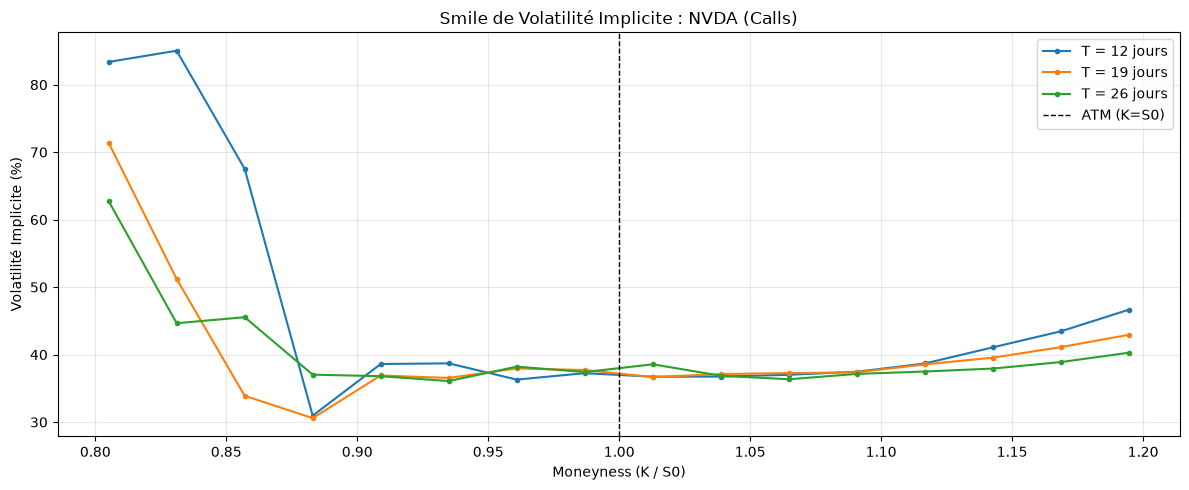

In [55]:
# On prend les 3 échéances les plus proches pour tracer le smile
echeances = sorted(calls_clean['T'].unique())[:3]

plt.figure(figsize=(12, 5))

for T_val in echeances:
    subset = calls_clean[calls_clean['T'] == T_val].sort_values('K')
    label = f"T = {T_val*365:.0f} jours"
    plt.plot(subset['K'] / S0_current, subset['my_IV'] * 100, marker='o', markersize=3, label=label)

plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1, label="ATM (K=S0)")
plt.title("Smile de Volatilité Implicite : NVDA (Calls)")
plt.xlabel("Moneyness (K / S0)")
plt.ylabel("Volatilité Implicite (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

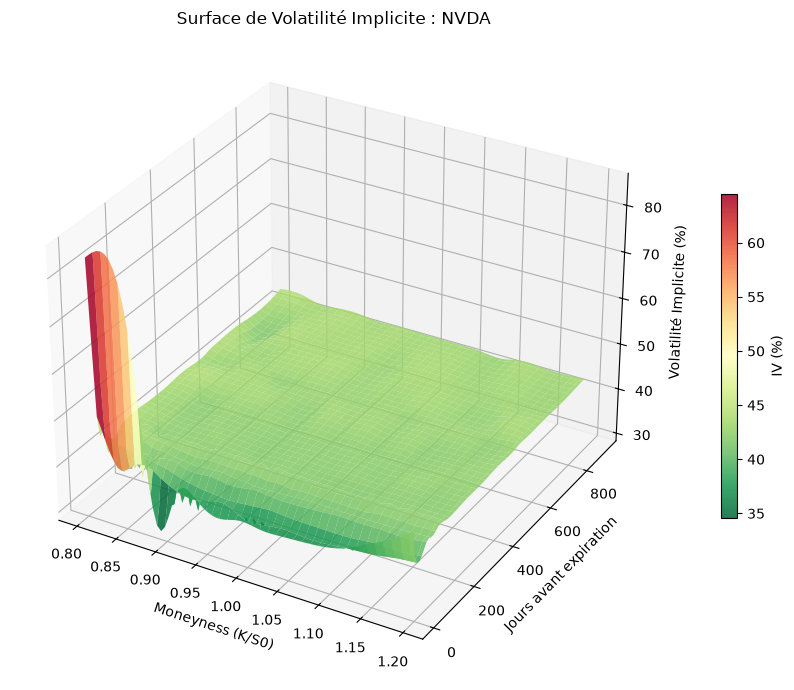

In [56]:
moneyness = calls_clean['K'].values / S0_current
maturite  = calls_clean['T'].values * 365
iv        = calls_clean['my_IV'].values * 100

if len(calls_clean) >= 4:
    grid_x = np.linspace(moneyness.min(), moneyness.max(), 80)
    grid_y = np.linspace(maturite.min(),  maturite.max(),  80)
    grid_X, grid_Y = np.meshgrid(grid_x, grid_y)

    grid_Z = griddata(
        points=(moneyness, maturite),
        values=iv,
        xi=(grid_X, grid_Y),
        method='cubic'
    )

    fig = plt.figure(figsize=(13, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(grid_X, grid_Y, grid_Z, cmap='RdYlGn_r', alpha=0.85, edgecolor='none')
    fig.colorbar(surf, ax=ax, shrink=0.5, label='IV (%)')
    ax.set_xlabel("Moneyness (K/S0)")
    ax.set_ylabel("Jours avant expiration")
    ax.set_zlabel("Volatilité Implicite (%)")
    ax.set_title("Surface de Volatilité Implicite : NVDA")
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez de points pour interpoler une surface 3D.")

## Interprétation & Résultats

### Fenêtre de moneyness retenue : [0.80, 1.20]

Le filtre initial [0.10, 1.90] générait 315 NaN sur les options deep ITM
(moneyness < 0.20) : le mid_price y est inférieur à la lower bound
théorique de no-arbitrage à cause du spread bid/ask, rendant l'inversion
BSM impossible. Ce n'est pas un bug, c'est une limite structurelle du
modèle sur des options très en dedans de la monnaie.

La zone [0.80, 1.20] correspond à la fenêtre liquide standard utilisée
en pratique pour construire une surface exploitable. Sur cette fenêtre,
314 / 314 contrats ont une IV calculée avec succès (MAE vs Yahoo : 4.96%).

### Écart avec Yahoo Finance (MAE ~5%)

Yahoo Finance calcule l'IV avec un modèle binomial intégrant les dividendes
discrets, alors que notre pricer utilise BSM sans dividendes. L'écart est
donc structurel et attendu, ce n'est pas une erreur d'implémentation.
La médiane à 4.98% confirme que l'écart est systématique, non aléatoire.

---

### Ce que les graphiques montrent

**Volatility Skew (NVDA : Smile)**

L'IV décroît fortement quand la moneyness augmente depuis 0.80 vers 1.0,
puis se stabilise autour de 35-40% ATM, et remonte légèrement côté OTM
droit (calls spéculatifs). Ce skew asymétrique, caractéristique du
"smirk" equity, reflète la prime de risque payée par les institutionnels
pour se couvrir contre un krach via l'achat massif de puts OTM.

Sur NVDA spécifiquement, ce skew est particulièrement prononcé pour
plusieurs raisons structurelles :
- Exposition directe aux export controls américains vers la Chine (H100, H20)
- Dépendance quasi-totale à TSMC pour la fabrication (risque géopolitique Taiwan)
- Concentration du revenu sur les datacenters IA : sensibilité forte
  aux cycles de capex des hyperscalers (Microsoft, Google, Meta, Amazon)

L'IV ATM à ~35-40% est cohérente avec le profil historique de NVDA,
titre structurellement plus volatil que le marché large (S&P 500 ~15-20%).

**Term Structure**

Sur les 3 échéances courtes tracées (12, 19, 26 jours), les courbes
convergent près de l'ATM. La term structure n'est pas visible sur des
maturités aussi proches ; pour l'observer, il faudrait comparer des
échéances plus espacées (1 mois vs 6 mois vs 2 ans).

**Surface de Volatilité Implicite (NVDA)**

La surface confirme le skew : falaise prononcée côté deep OTM gauche
(IV ~80% pour moneyness 0.80, toutes maturités), plateau stable à
35-40% sur la zone ATM/OTM droit, et légère remontée sur les longues
maturités reflétant l'incertitude structurelle long-terme sur NVDA
(cycles de capex IA, concurrence AMD/Intel, risque réglementaire).

---

### Ce que Black-Scholes ne peut pas reproduire

La surface n'est pas plate. BSM suppose σ constant, ce qui est
empiriquement faux et c'est précisément ce que ce notebook démontre.

Deux extensions permettent de fitter l'ensemble de la surface :
- **Heston** : la volatilité σ devient elle-même un processus stochastique
  (second mouvement brownien corrélé au premier), permettant de reproduire
  le skew et la term structure simultanément.
- **SABR** : modèle analytique très utilisé sur les desks de taux et
  de change, adapté aux surfaces avec skew fort.

En production, la donnée utilisée serait :
- **CBOE LiveVol** ou **Bloomberg** pour des snapshots tick-by-tick complets
- **IBKR API** pour des cotations temps réel avec book complet

Ces sources donnent accès aux options ATM manquantes (peu actives
hors heures de marché sur Yahoo Finance) et permettent de construire
une surface sans trous d'interpolation.